# NextTrack - Spotify Dataset Exploration

**Objective**: Explore the Kaggle Spotify dataset to:
1. Understand data structure and quality
2. Check if audio features are already normalized
3. Decide on database schema design (normalization level)
4. Identify any data cleaning needs

**Dataset Source**: https://www.kaggle.com/datasets/melissamonfared/spotify-tracks-attributes-and-popularity/data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load Dataset

In [3]:
# Load the CSV
df = pd.read_csv('../Data/dataset.csv')

print(f"✅ Loaded {len(df):,} tracks")
print(f"✅ {df.shape[1]} columns")
df.head()

✅ Loaded 114,000 tracks
✅ 21 columns


,index,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


## 2. Data Structure & Info

In [4]:
# Column types and null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   index             114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

In [5]:
# Statistical summary
df.describe()

,index,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


## 3. CRITICAL QUESTION: Are Audio Features Already Normalized?

Check if features are in 0-1 range (Spotify API standard)

In [6]:
# Audio features that SHOULD be 0-1 normalized
normalized_features = [
    'danceability', 'energy', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness', 'valence'
]

# Check min/max for each
print("Audio Feature Ranges (should be 0-1):")
print("=" * 50)
for feature in normalized_features:
    min_val = df[feature].min()
    max_val = df[feature].max()
    status = "✅ NORMALIZED" if (min_val >= 0 and max_val <= 1) else "❌ NOT NORMALIZED"
    print(f"{feature:20s}: [{min_val:.4f}, {max_val:.4f}] {status}")

print("\nOther Features (NOT 0-1):")
print("=" * 50)
for feature in ['tempo', 'loudness', 'key', 'mode', 'time_signature', 'duration_ms']:
    print(f"{feature:20s}: [{df[feature].min():.2f}, {df[feature].max():.2f}]")

Audio Feature Ranges (should be 0-1):
danceability        : [0.0000, 0.9850] ✅ NORMALIZED
energy              : [0.0000, 1.0000] ✅ NORMALIZED
speechiness         : [0.0000, 0.9650] ✅ NORMALIZED
acousticness        : [0.0000, 0.9960] ✅ NORMALIZED
instrumentalness    : [0.0000, 1.0000] ✅ NORMALIZED
liveness            : [0.0000, 1.0000] ✅ NORMALIZED
valence             : [0.0000, 0.9950] ✅ NORMALIZED

Other Features (NOT 0-1):
tempo               : [0.00, 243.37]
loudness            : [-49.53, 4.53]
key                 : [0.00, 11.00]
mode                : [0.00, 1.00]
time_signature      : [0.00, 5.00]
duration_ms         : [0.00, 5237295.00]


## 4. Data Quality Checks

In [7]:
# Missing values
print("Missing Values:")
print(df.isnull().sum())
print(f"\n% Missing: {(df.isnull().sum().sum() / (len(df) * len(df.columns)) * 100):.2f}%")

Missing Values:
index               0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

% Missing: 0.00%


In [8]:
# Duplicate track_ids (should be unique!)
duplicates = df['track_id'].duplicated().sum()
print(f"Duplicate track_ids: {duplicates:,}")

if duplicates > 0:
    print("\n⚠️ WARNING: Duplicate track IDs found!")
    print(df[df['track_id'].duplicated(keep=False)].head(10))

Duplicate track_ids: 24,259

⚠️ WARNING: Duplicate track IDs found!
    index                track_id                               artists  \
0       0  5SuOikwiRyPMVoIQDJUgSV                           Gen Hoshino   
1       1  4qPNDBW1i3p13qLCt0Ki3A                          Ben Woodward   
5       5  01MVOl9KtVTNfFiBU9I7dc                          Tyrone Wells   
6       6  6Vc5wAMmXdKIAM7WUoEb7N  A Great Big World;Christina Aguilera   
7       7  1EzrEOXmMH3G43AXT1y7pA                            Jason Mraz   
9       9  7k9GuJYLp2AzqokyEdwEw2                        Ross Copperman   
12     12  4ptDJbJl35d7gQfeNteBwp                              Dan Berk   
13     13  0X9MxHR1rTkEHDjp95F2OO                         Anna Hamilton   
16     16  6xKeQgzfjixSUld14qUezm                  Andrew Foy;Renee Foy   
17     17  4Yo0igmcoNyat1secaH0OD                  Andrew Foy;Renee Foy   

                             album_name             track_name  popularity  \
0                           

## 5. Feature Distribution Visualizations

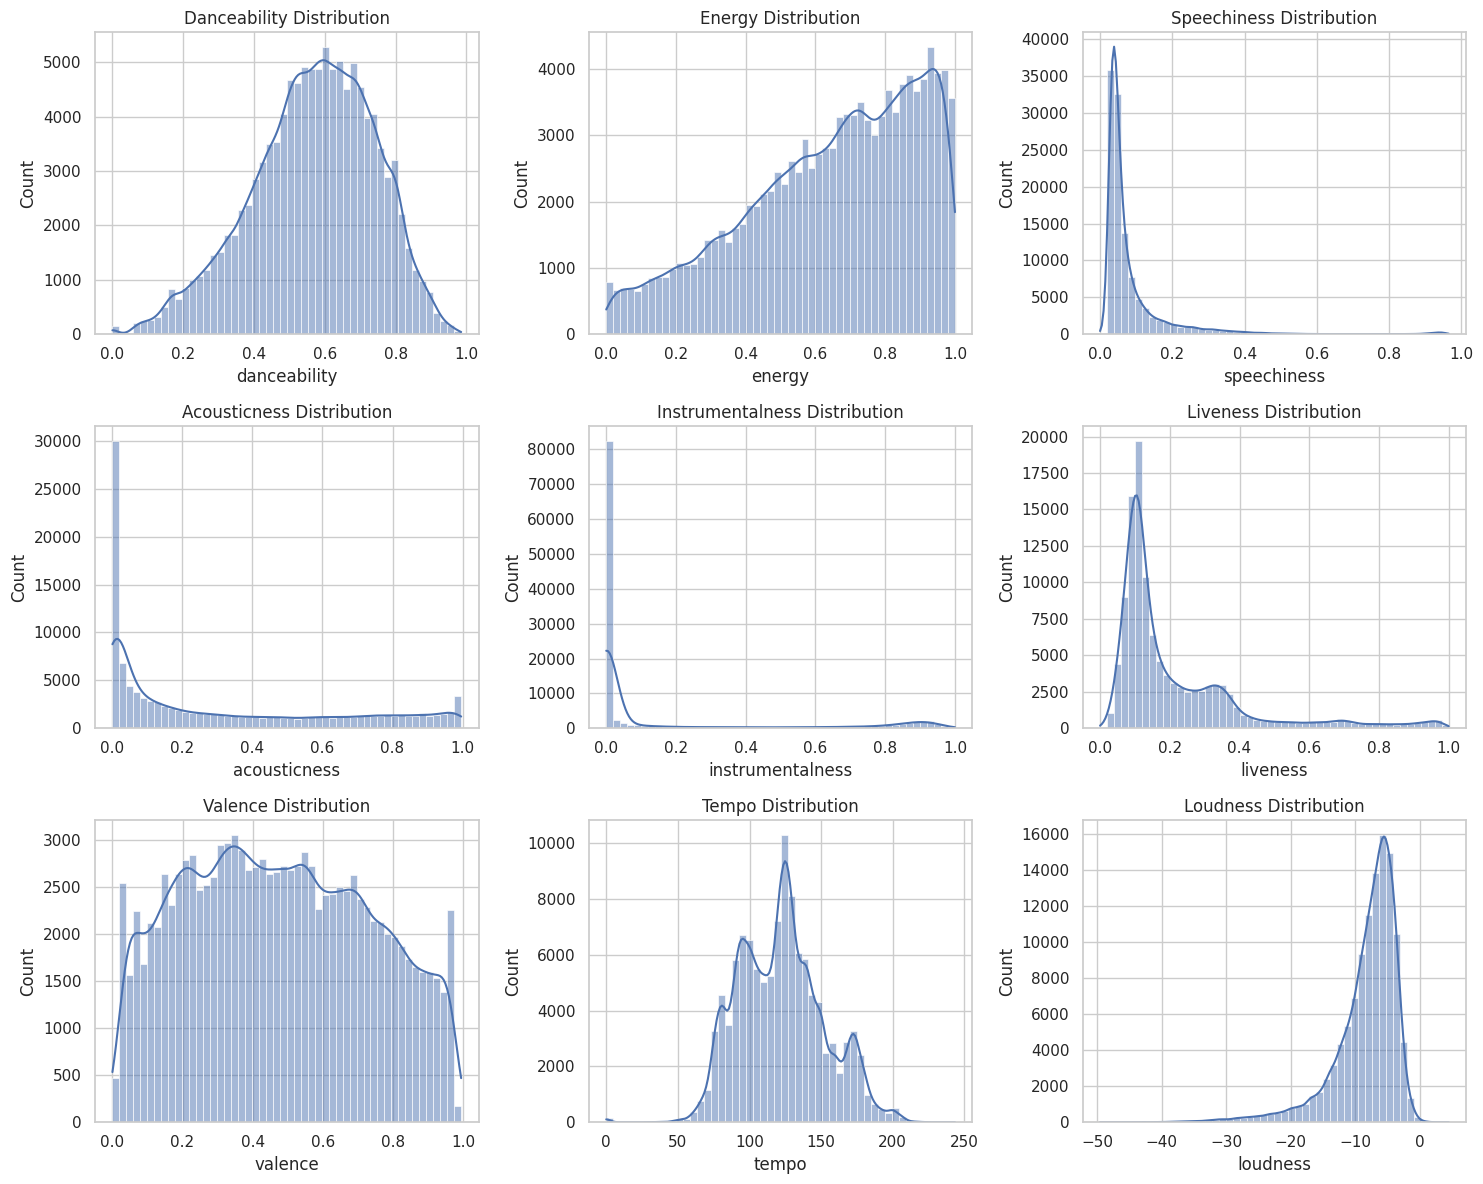

In [9]:
# Plot distributions for normalized features
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

features_to_plot = normalized_features + ['tempo', 'loudness']

for idx, feature in enumerate(features_to_plot):
    if idx < len(axes):
        sns.histplot(df[feature], bins=50, kde=True, ax=axes[idx])
        axes[idx].set_title(f'{feature.capitalize()} Distribution')
        axes[idx].set_xlabel(feature)

plt.tight_layout()
plt.show()

## 6. Database Schema Decision

### Option A: Single Table (Denormalized - Fast to implement)
```sql
tracks (
  id, track_id, artists, album_name, track_name,
  popularity, duration_ms, explicit, track_genre,
  danceability, energy, key, loudness, mode,
  speechiness, acousticness, instrumentalness,
  liveness, valence, tempo, time_signature
)
```

### Option B: Normalized Schema (Proper relational design)
```sql
artists (id, name)
albums (id, name)
tracks (id, track_id, name, album_id, ...)
audio_features (track_id, energy, valence, ...)
track_artists (track_id, artist_id)
```

Let's analyze the data to help decide:

In [10]:
# Check artist field - is it single or multiple?
print("Sample artist values:")
print(df['artists'].head(20))

# Count unique values
print(f"\nUnique tracks: {df['track_id'].nunique():,}")
print(f"Unique artists: {df['artists'].nunique():,}")
print(f"Unique albums: {df['album_name'].nunique():,}")
print(f"Unique genres: {df['track_genre'].nunique():,}")

Sample artist values:
0                              Gen Hoshino
1                             Ben Woodward
2                   Ingrid Michaelson;ZAYN
3                             Kina Grannis
4                         Chord Overstreet
5                             Tyrone Wells
6     A Great Big World;Christina Aguilera
7                               Jason Mraz
8                Jason Mraz;Colbie Caillat
9                           Ross Copperman
10                            Zack Tabudlo
11                              Jason Mraz
12                                Dan Berk
13                           Anna Hamilton
14                Chord Overstreet;Deepend
15                             Landon Pigg
16                    Andrew Foy;Renee Foy
17                    Andrew Foy;Renee Foy
18               Jason Mraz;Colbie Caillat
19                 Boyce Avenue;Bea Miller
Name: artists, dtype: object

Unique tracks: 89,741
Unique artists: 31,437
Unique albums: 46,589
Unique genres: 114


In [11]:
# Check for multi-artist tracks (separated by commas, semicolons, etc.)
multi_artist_tracks = df[df['artists'].str.contains(',|;|&', na=False)]
print(f"Tracks with multiple artists: {len(multi_artist_tracks):,} ({len(multi_artist_tracks)/len(df)*100:.1f}%)")
print("\nExamples:")
print(multi_artist_tracks[['track_name', 'artists']].head(10))

Tracks with multiple artists: 32,078 (28.1%)

Examples:
               track_name                               artists
2          To Begin Again                Ingrid Michaelson;ZAYN
6           Say Something  A Great Big World;Christina Aguilera
8                   Lucky             Jason Mraz;Colbie Caillat
14        Hold On - Remix              Chord Overstreet;Deepend
16  ily (i love you baby)                  Andrew Foy;Renee Foy
17            At My Worst                  Andrew Foy;Renee Foy
18                  Lucky             Jason Mraz;Colbie Caillat
19             Photograph               Boyce Avenue;Bea Miller
21                 Demons            Boyce Avenue;Jennel Garcia
22          Say Something  A Great Big World;Christina Aguilera


## 7. Genre Distribution

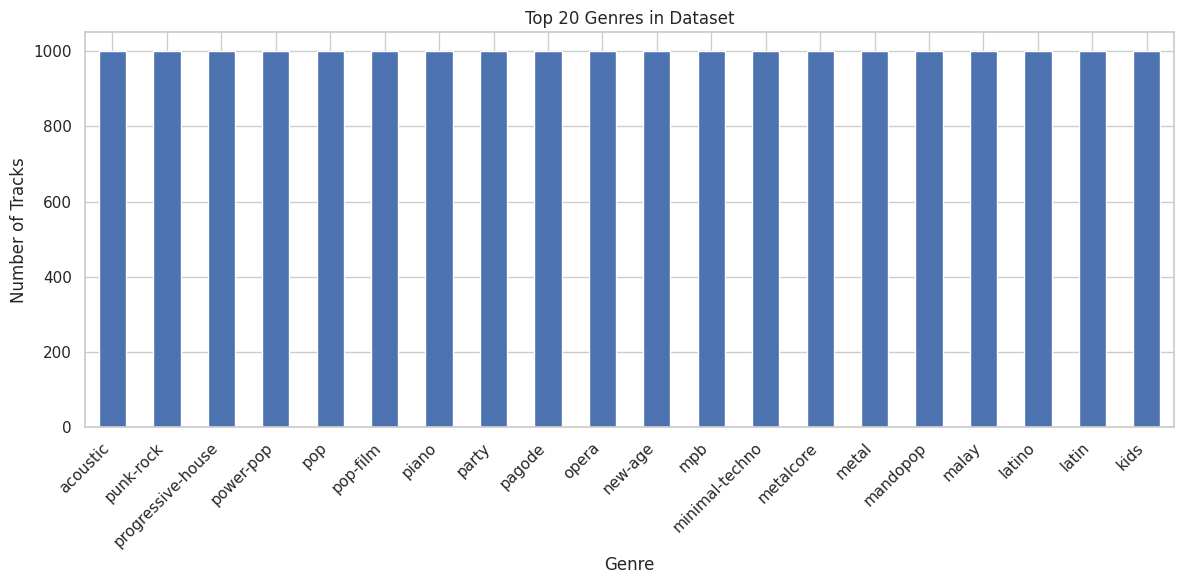

Total unique genres: 114


In [12]:
# Top 20 genres
genre_counts = df['track_genre'].value_counts().head(20)

plt.figure(figsize=(12, 6))
genre_counts.plot(kind='bar')
plt.title('Top 20 Genres in Dataset')
plt.xlabel('Genre')
plt.ylabel('Number of Tracks')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"Total unique genres: {df['track_genre'].nunique()}")

## 8. Popularity Analysis

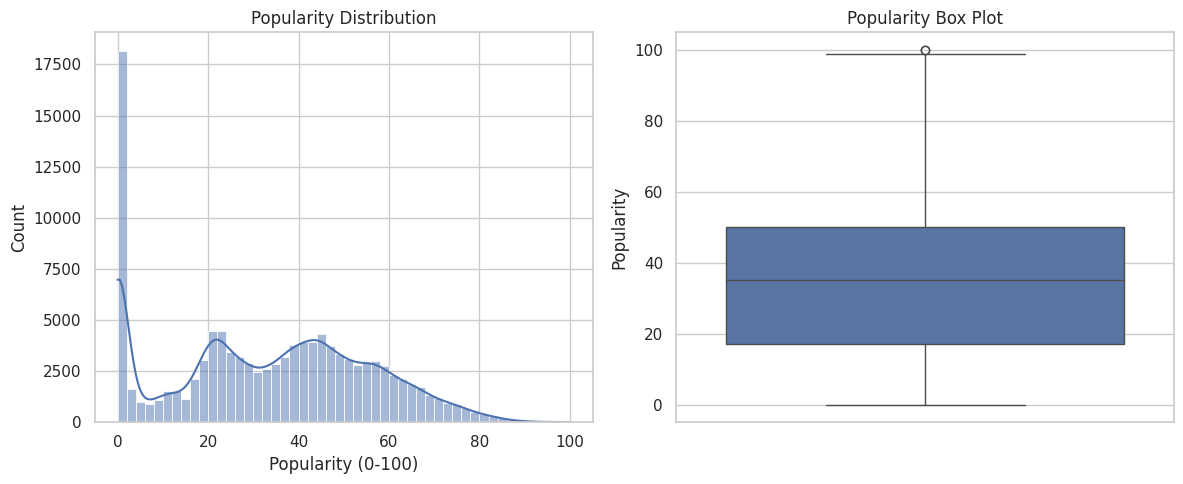

Mean popularity: 33.24
Median popularity: 35.00


In [13]:
# Popularity distribution
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['popularity'], bins=50, kde=True)
plt.title('Popularity Distribution')
plt.xlabel('Popularity (0-100)')

plt.subplot(1, 2, 2)
sns.boxplot(y=df['popularity'])
plt.title('Popularity Box Plot')
plt.ylabel('Popularity')

plt.tight_layout()
plt.show()

print(f"Mean popularity: {df['popularity'].mean():.2f}")
print(f"Median popularity: {df['popularity'].median():.2f}")

## 9. Correlation Analysis

Which audio features correlate with popularity?

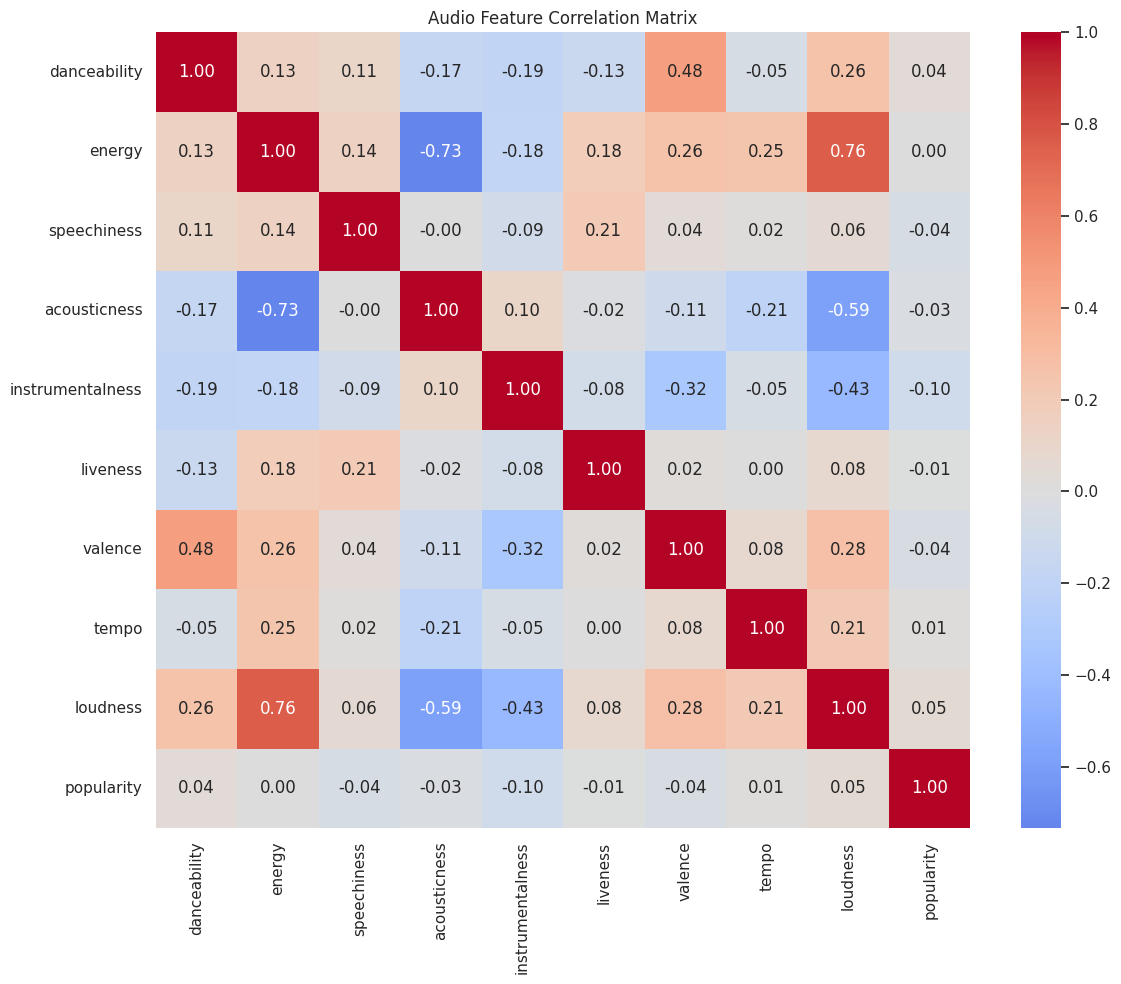


Features most correlated with POPULARITY:
popularity          1.000000
loudness            0.050423
danceability        0.035448
tempo               0.013205
energy              0.001056
liveness           -0.005387
acousticness       -0.025472
valence            -0.040534
speechiness        -0.044927
instrumentalness   -0.095139
Name: popularity, dtype: float64


In [14]:
# Correlation matrix for audio features + popularity
features_for_corr = normalized_features + ['tempo', 'loudness', 'popularity']
corr_matrix = df[features_for_corr].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Audio Feature Correlation Matrix')
plt.tight_layout()
plt.show()

# What correlates most with popularity?
print("\nFeatures most correlated with POPULARITY:")
print(corr_matrix['popularity'].sort_values(ascending=False))

## 10. Recommendation: Database Schema Design

Based on the exploration above, decide:

**For Prototype (Quick Implementation):**
- Use **Option A (Single Table)** if we want to get working fast
- Less complex queries (no JOINs needed)
- Easier to migrate from CSV

**For Production (Proper Design):**
- Use **Option B (Normalized)** for cleaner architecture
- Handle multi-artist tracks properly
- Reduce data redundancy

### Proposed Simple Schema (Recommended for Prototype):

```sql
CREATE TABLE tracks (
    id SERIAL PRIMARY KEY,
    track_id VARCHAR(50) UNIQUE NOT NULL,  -- Spotify ID
    track_name TEXT NOT NULL,
    artists TEXT NOT NULL,                 -- Store as-is from CSV
    album_name TEXT,
    track_genre VARCHAR(100),
    popularity INTEGER,
    duration_ms INTEGER,
    explicit BOOLEAN,
    
    -- Audio features (already normalized 0-1)
    danceability FLOAT,
    energy FLOAT,
    speechiness FLOAT,
    acousticness FLOAT,
    instrumentalness FLOAT,
    liveness FLOAT,
    valence FLOAT,
    
    -- Other audio attributes
    tempo FLOAT,
    loudness FLOAT,
    key INTEGER,
    mode INTEGER,
    time_signature INTEGER,
    
    created_at TIMESTAMP DEFAULT CURRENT_TIMESTAMP
);

-- Indexes for fast queries
CREATE INDEX idx_track_id ON tracks(track_id);
CREATE INDEX idx_genre ON tracks(track_genre);
CREATE INDEX idx_popularity ON tracks(popularity);
```

## 11. Summary & Next Steps

**Key Findings:**
1. ✅ Audio features ARE already normalized (0-1 range)
2. ✅ 114,000 tracks available
3. ⚠️ Check for duplicate track_ids
4. ℹ️ Multiple artists stored as comma-separated strings

**Decision Needed:**
- Which schema design? (Simple vs Normalized)
- How to handle multi-artist tracks?

**Next Steps:**
1. Install PostgreSQL
2. Create database and schema
3. Write data loading script
4. Update recommendation engine to query DB
5. Test!

In [ ]:
# Save cleaned dataset for loading (if needed)
# df_clean = df.drop_duplicates(subset=['track_id'])
# df_clean.to_csv('../Data/dataset_clean.csv', index=False)
# print(f"Saved {len(df_clean):,} unique tracks")